Analyse Exploratoire (EDA)
Objectif : comprendre les données avant de les toucher.

In [1]:
# ── Cellule 1 : Imports ────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('../data/fraudTrain.csv')
df_test  = pd.read_csv('../data/fraudTest.csv')

In [2]:
# ── Cellule 2 : Vue générale ───────────────────────────
print(df_train.shape)
df_train.head()
df_train.info()
df_train.describe()

(1296675, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [3]:
# ── Cellule 3 : Valeurs manquantes ────────────────────
df_train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13348\1719396495.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df_train, palette=['#2ecc71','#e74c3c'])


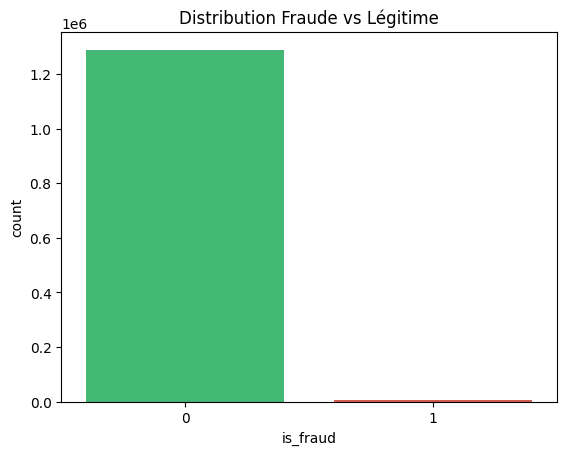

In [4]:
# ── Cellule 4 : Distribution de la cible ──────────────
fraud_rate = df_train['is_fraud'].value_counts(normalize=True) * 100
print(fraud_rate)
# Visualisation du déséquilibre
sns.countplot(x='is_fraud', data=df_train, palette=['#2ecc71','#e74c3c'])
plt.title("Distribution Fraude vs Légitime")
plt.show()

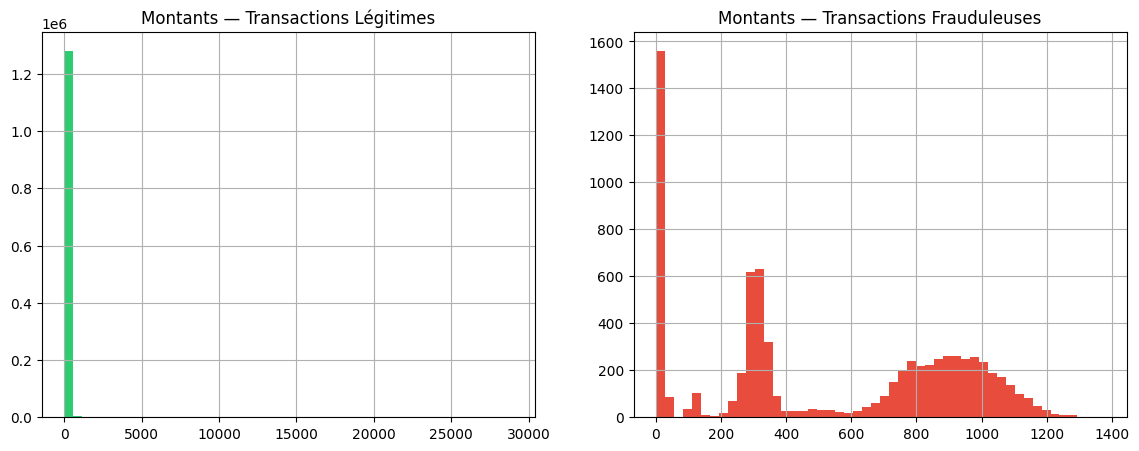

In [5]:
# ── Cellule 5 : Distribution du montant ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df_train[df_train['is_fraud']==0]['amt'].hist(bins=50, ax=axes[0], color='#2ecc71')
axes[0].set_title('Montants — Transactions Légitimes')
df_train[df_train['is_fraud']==1]['amt'].hist(bins=50, ax=axes[1], color='#e74c3c')
axes[1].set_title('Montants — Transactions Frauduleuses')
plt.show()

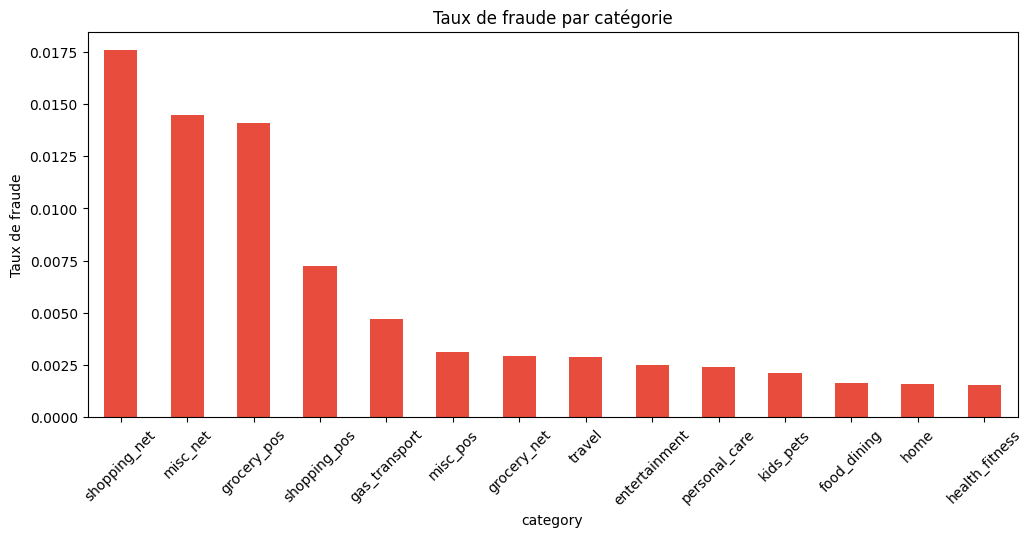

In [6]:
# ── Cellule 6 : Fraude par catégorie ──────────────────
fraud_by_cat = df_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_cat.plot(kind='bar', color='#e74c3c', figsize=(12,5))
plt.title("Taux de fraude par catégorie")
plt.ylabel("Taux de fraude")
plt.xticks(rotation=45)
plt.show()

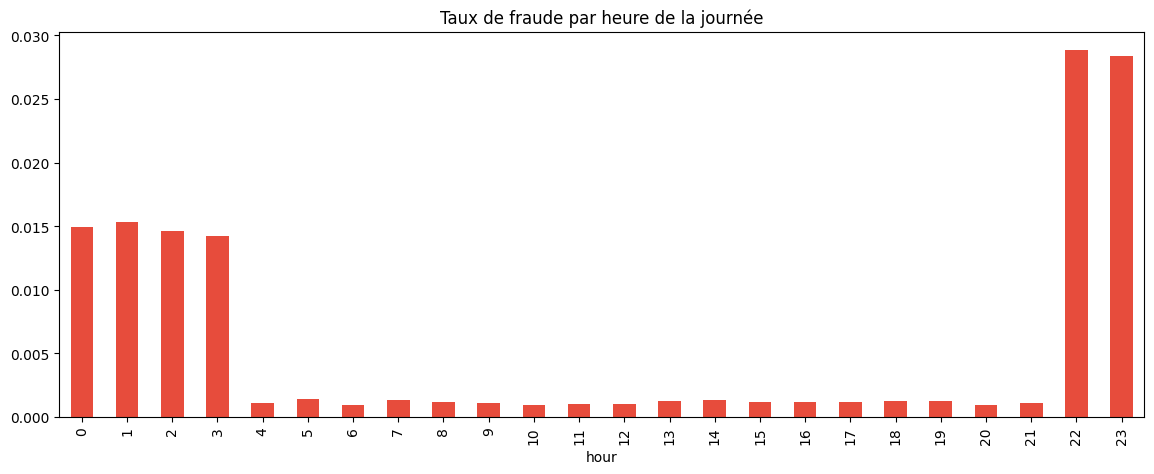

In [7]:
# ── Cellule 7 : Fraude par heure ──────────────────────
df_train['hour'] = pd.to_datetime(df_train['trans_date_trans_time']).dt.hour
fraud_by_hour = df_train.groupby('hour')['is_fraud'].mean()
fraud_by_hour.plot(kind='bar', figsize=(14,5), color='#e74c3c')
plt.title("Taux de fraude par heure de la journée")
plt.show()

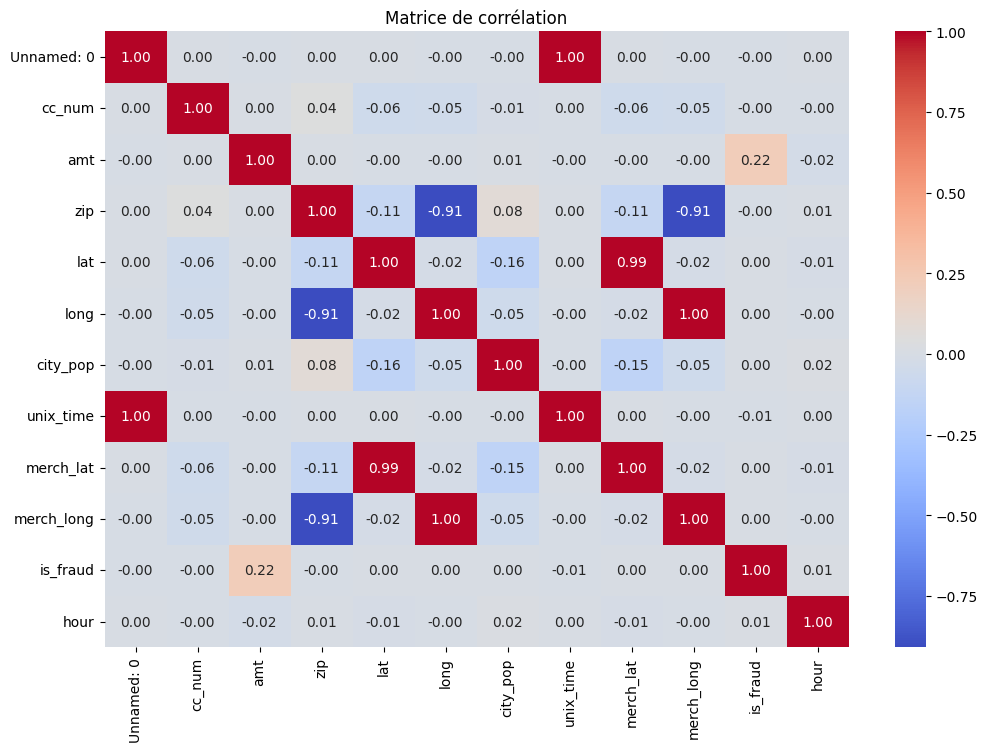

In [8]:
# ── Cellule 8 : Heatmap de corrélation ────────────────
numeric_cols = df_train.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation")
plt.show()